# Conversion of audios into mel spetcrogram

In [ ]:
!pip install librosa matplotlib

In [5]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: Mountpoint must not already contain files

In [3]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

input_base = "/content/drive/MyDrive/IAPC Project/Pre - Processed Dataset"

output_base = "/content/drive/MyDrive/IAPC Project/Spectrogram Dataset"

folders = [
    ("AI Voices", "AI English", "AI"),
    ("AI Voices", "AI Hindi", "AI"),
    ("Human Voices", "Human English", "Human"),
    ("Human Voices", "Human Hindi", "Human")
]

for main, sub, label in folders:

    input_folder = os.path.join(input_base, main, sub)
    output_folder = os.path.join(output_base, label)

    os.makedirs(output_folder, exist_ok=True)

    files = [f for f in os.listdir(input_folder) if f.endswith(".wav")]

    for file in files:
        file_path = os.path.join(input_folder, file)

        try:
            y, sr = librosa.load(file_path, sr=16000)

            mel_spec = librosa.feature.melspectrogram(
                y=y,
                sr=sr,
                n_mels=128,
                fmax=8000
            )

            mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

            plt.figure(figsize=(3, 3))
            librosa.display.specshow(mel_spec_db, sr=sr, cmap='magma')
            plt.axis('off')

            save_path = os.path.join(output_folder, file.replace(".wav", ".png"))
            plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
            plt.close()

        except Exception as e:
            print(f"Error: {file_path}")

    print(f"Done: {main} → {sub}")

print("All spectrograms generated!")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/IAPC Project/Pre - Processed Dataset/AI Voices/AI English'

In [ ]:
import os
import pandas as pd

base_path = "/content/drive/MyDrive/IAPC Project/Spectrogram Dataset"

data = []

folders = [
    ("AI", os.path.join(base_path, "AI")),
    ("Human", os.path.join(base_path, "Human"))
]

for label, folder_path in folders:

    files = [f for f in os.listdir(folder_path) if f.endswith(".png")]

    for file in files:
        file_path = os.path.join(folder_path, file)

        if "eng" in file.lower():
            language = "English"
        elif "hin" in file.lower():
            language = "Hindi"
        else:
            language = "Unknown"

        data.append({
            "file_path": file_path,
            "label": label,
            "language": language
        })

df = pd.DataFrame(data)

csv_path = os.path.join(base_path, "spectrogram_dataset.csv")
df.to_csv(csv_path, index=False)

print("CSV with language created!")

CSV with language created!


## CSV File Encoding for Model Training

In [ ]:
import pandas as pd

csv_path = "/content/drive/MyDrive/IAPC Project/Spectrogram Dataset/spectrogram_dataset.csv"

df = pd.read_csv(csv_path)

df["label_encoded"] = df["label"].map({
    "AI": 0,
    "Human": 1
})

df["language_encoded"] = df["language"].map({
    "English": 0,
    "Hindi": 1
})

new_csv_path = csv_path.replace(".csv", "_encoded.csv")
df.to_csv(new_csv_path, index=False)

print("Encoding done!")
print("Saved at:", new_csv_path)
print(df.head())

Encoding done!
Saved at: /content/drive/MyDrive/IAPC Project/Spectrogram Dataset/spectrogram_dataset_encoded.csv
                                           file_path label language  \
0  /content/drive/MyDrive/IAPC Project/Spectrogra...    AI  English   
1  /content/drive/MyDrive/IAPC Project/Spectrogra...    AI  English   
2  /content/drive/MyDrive/IAPC Project/Spectrogra...    AI  English   
3  /content/drive/MyDrive/IAPC Project/Spectrogra...    AI  English   
4  /content/drive/MyDrive/IAPC Project/Spectrogra...    AI  English   

   label_encoded  language_encoded  
0              0                 0  
1              0                 0  
2              0                 0  
3              0                 0  
4              0                 0  


# Dataset Uploadation

In [1]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms

In [2]:
csv_path = "/content/drive/MyDrive/IAPC Project/Spectrogram Dataset/spectrogram_dataset_encoded.csv"

df = pd.read_csv(csv_path)

df = df[["file_path", "label_encoded", "language_encoded"]]

print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/IAPC Project/Spectrogram Dataset/spectrogram_dataset_encoded.csv'

In [ ]:
df_eng = df[df["language_encoded"] == 0].reset_index(drop=True)

df_hin = df[df["language_encoded"] == 1].reset_index(drop=True)

print("English samples:", len(df_eng))
print("Hindi samples:", len(df_hin))

English samples: 706
Hindi samples: 992


In [ ]:
class SpectrogramDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "file_path"]
        label = self.df.loc[idx, "label_encoded"]

        image = Image.open(img_path).convert("L")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

In [ ]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [ ]:
# English dataset
dataset_eng = SpectrogramDataset(df_eng, transform=transform)

# Hindi dataset
dataset_hin = SpectrogramDataset(df_hin, transform=transform)

In [ ]:
from sklearn.model_selection import train_test_split

train_eng, val_eng = train_test_split(df_eng, test_size=0.2, random_state=42)
train_hin, val_hin = train_test_split(df_hin, test_size=0.2, random_state=42)

train_eng = train_eng.reset_index(drop=True)
val_eng = val_eng.reset_index(drop=True)

train_hin = train_hin.reset_index(drop=True)
val_hin = val_hin.reset_index(drop=True)

train_dataset_eng = SpectrogramDataset(train_eng, transform)
val_dataset_eng   = SpectrogramDataset(val_eng, transform)

train_dataset_hin = SpectrogramDataset(train_hin, transform)
val_dataset_hin   = SpectrogramDataset(val_hin, transform)

In [ ]:
batch_size = 32

train_loader_eng = DataLoader(train_dataset_eng, batch_size=batch_size, shuffle=True)
val_loader_eng   = DataLoader(val_dataset_eng, batch_size=batch_size, shuffle=False)

train_loader_hin = DataLoader(train_dataset_hin, batch_size=batch_size, shuffle=True)
val_loader_hin   = DataLoader(val_dataset_hin, batch_size=batch_size, shuffle=False)

# Training

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
class VoiceCNN(nn.Module):
    def __init__(self):
        super(VoiceCNN, self).__init__()

        # 🔹 Convolutional Layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(2, 2)

        # 🔹 Fully Connected Layers
        self.fc1 = nn.Linear(256 * 8 * 8, 256)   # adjust if image size changes
        self.dropout = nn.Dropout(0.3)

        self.fc2 = nn.Linear(256, 128)  # 🔥 FEATURE VECTOR

        self.fc3 = nn.Linear(128, 1)    # Output layer

    def forward(self, x, return_features=False):

        # 🔹 Conv Block 1
        x = self.pool(F.relu(self.bn1(self.conv1(x))))

        # 🔹 Conv Block 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        # 🔹 Conv Block 3
        x = self.pool(F.relu(self.bn3(self.conv3(x))))

        # 🔹 Conv Block 4
        x = self.pool(F.relu(self.bn4(self.conv4(x))))

        # 🔹 Flatten
        x = x.view(x.size(0), -1)

        # 🔹 Dense Layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        features = F.relu(self.fc2(x))  # 🔥 This is what you'll extract

        output = torch.sigmoid(self.fc3(features))

        if return_features:
            return features

        return output

In [ ]:
model = VoiceCNN() # write it as model_eng

criterion = torch.nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0

    for images, labels in train_loader_eng:

        # Forward pass
        outputs = model(images).squeeze()

        loss = criterion(outputs, labels)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss:.4f}")

Epoch [1/10], Loss: 8.3056
Epoch [2/10], Loss: 5.2826
Epoch [3/10], Loss: 2.8643
Epoch [4/10], Loss: 1.5939
Epoch [5/10], Loss: 0.8472
Epoch [6/10], Loss: 0.4115
Epoch [7/10], Loss: 0.3083
Epoch [8/10], Loss: 0.2670
Epoch [9/10], Loss: 0.1448
Epoch [10/10], Loss: 0.0951


In [ ]:
print(images.shape)

torch.Size([20, 1, 128, 128])


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader_eng:

        outputs = model(images).squeeze()
        preds = (outputs > 0.5).float()

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.9859154929577465


In [ ]:
model_hin = VoiceCNN()

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()

    running_loss = 0.0

    for images, labels in train_loader_hin:

        # Forward pass
        outputs = model(images).squeeze()

        loss = criterion(outputs, labels)

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss:.4f}")

Epoch [1/10], Loss: 8.4440
Epoch [2/10], Loss: 3.3582
Epoch [3/10], Loss: 2.1080
Epoch [4/10], Loss: 1.1957
Epoch [5/10], Loss: 1.0202
Epoch [6/10], Loss: 0.5032
Epoch [7/10], Loss: 0.3604
Epoch [8/10], Loss: 0.2469
Epoch [9/10], Loss: 0.1853
Epoch [10/10], Loss: 0.1444


In [ ]:
model_hin.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader_hin:

        outputs = model(images).squeeze()
        preds = (outputs > 0.5).float()

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.9949748743718593


In [ ]:
model.eval()
model_hin.eval()

VoiceCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=16384, out_features=256, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=1, bias=True)
)

In [ ]:
def extract_features(model1, dataloader):
    features_list = []
    labels_list = []

    model1.eval()

    with torch.no_grad():
        for images, labels in dataloader:

            outputs = model1(images, return_features=True)

            features_list.append(outputs.cpu())
            labels_list.append(labels.cpu())

    features = torch.cat(features_list)
    labels = torch.cat(labels_list)

    return features, labels

In [ ]:
features_eng, labels_eng = extract_features(model, val_loader_eng)

In [ ]:
features_hin, labels_hin = extract_features(model_hin, val_loader_hin)

In [ ]:
features_eng = features_eng.numpy()
labels_eng = labels_eng.numpy()

features_hin = features_hin.numpy()
labels_hin = labels_hin.numpy()

In [ ]:
# English
ai_eng = features_eng[labels_eng == 0]
human_eng = features_eng[labels_eng == 1]

# Hindi
ai_hin = features_hin[labels_hin == 0]
human_hin = features_hin[labels_hin == 1]

## Cosine Similarity check

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

In [ ]:
sim_eng = cosine_similarity(ai_eng, human_eng)
sim_hin = cosine_similarity(ai_hin, human_hin)

print("English AI-Human similarity:", np.mean(sim_eng))
print("Hindi AI-Human similarity:", np.mean(sim_hin))

English AI-Human similarity: 0.8539841
Hindi AI-Human similarity: 0.9984269


## Internal Comparisons

In [ ]:
# Human vs Human
sim_human_eng = cosine_similarity(human_eng, human_eng)

# AI vs AI
sim_ai_eng = cosine_similarity(ai_eng, ai_eng)

## tSNE Plot

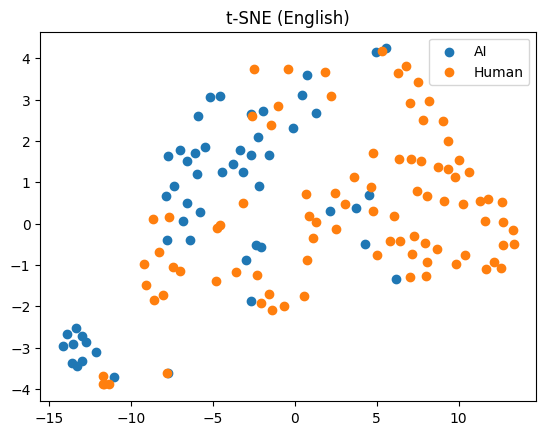

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2)

reduced = tsne.fit_transform(features_eng)

plt.scatter(reduced[labels_eng==0,0], reduced[labels_eng==0,1], label="AI")
plt.scatter(reduced[labels_eng==1,0], reduced[labels_eng==1,1], label="Human")
plt.legend()
plt.title("t-SNE (English)")
plt.show()

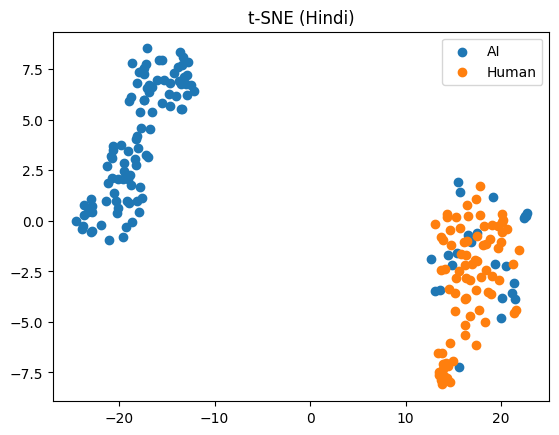

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2)

reduced = tsne.fit_transform(features_hin)

plt.scatter(reduced[labels_hin==0,0], reduced[labels_hin==0,1], label="AI")
plt.scatter(reduced[labels_hin==1,0], reduced[labels_hin==1,1], label="Human")
plt.legend()
plt.title("t-SNE (Hindi)")
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def paired_similarity(A, B):
    n = min(len(A), len(B))
    sims = []
    for i in range(n):
        sims.append(
            cosine_similarity(A[i].reshape(1,-1),
                              B[i].reshape(1,-1))[0,0]
        )
    return np.array(sims)

def within_similarity(X, k=200):
    # sample k pairs to avoid O(N^2)
    idx = np.random.choice(len(X), size=min(k, len(X)), replace=False)
    sims = []
    for i in idx:
        j = np.random.randint(0, len(X))
        sims.append(cosine_similarity(X[i].reshape(1,-1),
                                      X[j].reshape(1,-1))[0,0])
    return np.array(sims)

# English
sim_e_ah = paired_similarity(ai_eng, human_eng)
sim_e_aa = within_similarity(ai_eng)
sim_e_hh = within_similarity(human_eng)

# Hindi
sim_h_ah = paired_similarity(ai_hin, human_hin)
sim_h_aa = within_similarity(ai_hin)
sim_h_hh = within_similarity(human_hin)

print("English:", sim_e_ah.mean(), sim_e_aa.mean(), sim_e_hh.mean())
print("Hindi:",   sim_h_ah.mean(), sim_h_aa.mean(), sim_h_hh.mean())

English: 0.85610265 0.8831475 0.91047096
Hindi: 0.9984501 0.9993029 0.9997621


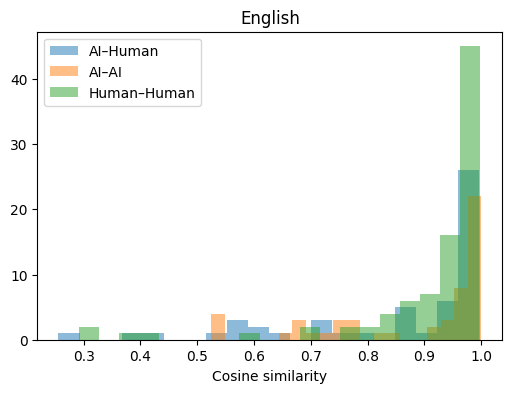

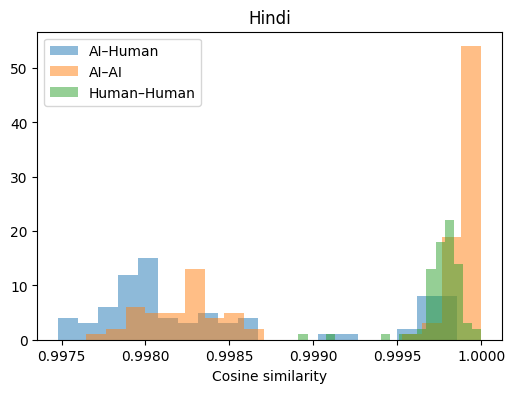

In [ ]:
import matplotlib.pyplot as plt

def plot_hist(title, ah, aa, hh):
    plt.figure(figsize=(6,4))
    plt.hist(ah, bins=20, alpha=0.5, label="AI–Human")
    plt.hist(aa, bins=20, alpha=0.5, label="AI–AI")
    plt.hist(hh, bins=20, alpha=0.5, label="Human–Human")
    plt.legend(); plt.title(title); plt.xlabel("Cosine similarity"); plt.show()

plot_hist("English", sim_e_ah, sim_e_aa, sim_e_hh)
plot_hist("Hindi",   sim_h_ah, sim_h_aa, sim_h_hh)

In [ ]:
from sklearn.metrics import silhouette_score

X_eng = np.vstack([ai_eng, human_eng])
y_eng = np.array([0]*len(ai_eng) + [1]*len(human_eng))

X_hin = np.vstack([ai_hin, human_hin])
y_hin = np.array([0]*len(ai_hin) + [1]*len(human_hin))

print("Silhouette (English):", silhouette_score(X_eng, y_eng))
print("Silhouette (Hindi):",   silhouette_score(X_hin, y_hin))

Silhouette (English): 0.16522147
Silhouette (Hindi): 0.4768512


In [ ]:
diff_eng = np.abs(ai_eng.mean(axis=0) - human_eng.mean(axis=0))
diff_hin = np.abs(ai_hin.mean(axis=0) - human_hin.mean(axis=0))

# top-k dimensions that differ most
k = 10
top_eng = np.argsort(diff_eng)[-k:]
top_hin = np.argsort(diff_hin)[-k:]

print("Top differing dims (English):", top_eng)
print("Top differing dims (Hindi):",   top_hin)

Top differing dims (English): [ 53 104  51  91  54 107 123   1 106  88]
Top differing dims (Hindi): [ 62  77  28  67  26 112  45  84 105  81]
